# Unit12_Example_05 | 管型反應器之最佳操作溫度分布

本 Notebook 結合 `scipy.integrate.solve_ivp()` 與 `scipy.optimize.minimize(method='SLSQP')` 求解管型反應器之最佳操作溫度分布問題。

## 目標
- 建立含溫度依賴速率常數之連串反應 ODE 模型（ $A \to B \to C$ ）
- 以分段均勻溫度參數化將動態最適化問題轉換為靜態 NLP
- 使用 SLSQP 嵌套 `solve_ivp()` 求解最佳溫度分布，最大化產物 B 之終端濃度 $x_2(t_f)$
- 探討時間分割區段數 $n$ 對最佳解品質的影響
- 繪製最佳溫度分布階梯圖與系統狀態隨時間之變化曲線

資料來源：改編自教科書 ch6 範例 6-2-7

---
### 0. 環境設定

In [9]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit12_Example_05'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit12'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit12
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Example_05
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Example_05\figs


---
### 1. 載入套件

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.integrate import solve_ivp
from scipy.optimize import minimize, Bounds

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
print(f"  numpy      版本: {np.__version__}")
import scipy
print(f"  scipy      版本: {scipy.__version__}")
import matplotlib
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 問題描述

管型反應器中進行連串反應 $A \to B \to C$ （含逆反應 $B \to A$ ），以 $x_1$ 、 $x_2$ 分別表示 $A$ 與 $B$ 之無因次濃度：

$$
\frac{dx_1}{dt} = -k_1(T)\,x_1^2 + k_2(T)\,x_2
$$

$$
\frac{dx_2}{dt} = k_1(T)\,x_1^2 - [k_2(T) + k_3(T)]\,x_2
$$

初始條件： $x_1(0) = 1.0$ ， $x_2(0) = 0.0$ ；反應時間 $t \in [0, 1]$ （無因次）。

**Arrhenius 速率常數**：

$$
k_i(T) = k_{i0} \exp\!\left(-\frac{E_i}{T}\right)
$$

其中 $k_{10} = 4000$ ， $E_1 = 2500\ \text{K}$ ； $k_{20} = 2000$ ， $E_2 = 2000\ \text{K}$ ； $k_{30} = 1000$ ， $E_3 = 3000\ \text{K}$ 。

**最適化問題**：決定溫度分布 $T(t)$ ，使終端產物 B 濃度最大：

$$
\max_{T(t)} \; x_2(t_f), \quad T_{\min} \leq T(t) \leq T_{\max}
$$

**分段均勻溫度參數化**：將 $[0,1]$ 分為 $n$ 段，各段溫度 $T_j$ 為決策變數（共 $n$ 個），溫度操作範圍 $T \in [298,\ 698]\ \text{K}$ 。

In [11]:
# ========================================
# 反應動力學參數
# ========================================
# Arrhenius 參數: k_i(T) = k_i0 * exp(-E_i / T)
k10, E1 = 4000.0, 2500.0   # A → B (主反應)
k20, E2 = 2000.0, 2000.0   # B → A (逆反應)
k30, E3 = 1000.0, 3000.0   # B → C (副反應)

# 初始條件
x0_reactor = np.array([1.0, 0.0])  # [x1(0), x2(0)]

# 反應時間 (無因次)
T_FINAL = 1.0

# 溫度操作範圍 (K)
T_MIN = 298.0
T_MAX = 698.0

print("✓ 反應動力學參數設定完成")
print(f"\n速率常數 (參數):")
print(f"  k1: k10={k10:.0f}, E1={E1:.0f} K  (A→B, 主反應)")
print(f"  k2: k20={k20:.0f}, E2={E2:.0f} K  (B→A, 逆反應)")
print(f"  k3: k30={k30:.0f}, E3={E3:.0f} K  (B→C, 副反應)")
print(f"\n初始條件: x1(0)={x0_reactor[0]:.1f}, x2(0)={x0_reactor[1]:.1f}")
print(f"反應時間: t ∈ [0, {T_FINAL}] (無因次)")
print(f"溫度範圍: [{T_MIN:.0f}, {T_MAX:.0f}] K")

# 不同溫度下速率常數示例
print("\n不同溫度下速率常數示例:")
print(f"{'T (K)':>8} {'k1':>10} {'k2':>10} {'k3':>10}")
print("-" * 42)
for T in [350, 450, 550, 650]:
    k1 = k10 * np.exp(-E1 / T)
    k2 = k20 * np.exp(-E2 / T)
    k3 = k30 * np.exp(-E3 / T)
    print(f"{T:>8} {k1:>10.4f} {k2:>10.4f} {k3:>10.4f}")

✓ 反應動力學參數設定完成

速率常數 (參數):
  k1: k10=4000, E1=2500 K  (A→B, 主反應)
  k2: k20=2000, E2=2000 K  (B→A, 逆反應)
  k3: k30=1000, E3=3000 K  (B→C, 副反應)

初始條件: x1(0)=1.0, x2(0)=0.0
反應時間: t ∈ [0, 1.0] (無因次)
溫度範圍: [298, 698] K

不同溫度下速率常數示例:
   T (K)         k1         k2         k3
------------------------------------------
     350     3.1620     6.5970     0.1894
     450    15.4637    23.4873     1.2726
     550    42.4614    52.6960     4.2768
     650    85.4470    92.2018     9.8984


---
### 3. ODE 模型與目標函數

**求解策略說明**：

1. `reactor_ode(t, y, T)` — 定義 ODE 右側（含 Arrhenius 速率計算）
2. `integrate_reactor(T_profile)` — 逐段積分：依 `T_profile` 長度自動分段，對每個時間區間以該段均一溫度呼叫 `solve_ivp()`，銜接各段初始條件
3. `objective(T_profile)` — 目標函數：呼叫 `integrate_reactor()` 後取 $-x_2(t_f)$ （最小化負值 = 最大化）

```
SLSQP
  └─ objective(T_profile)
        └─ integrate_reactor(T_profile)
              └─ solve_ivp(reactor_ode, ...) × n 段
```

**注意**：每次 SLSQP 評估目標函數都需完整積分 $n$ 段 ODE，計算量與 $n$ 成正比。

In [12]:
def reactor_ode(t, y, T):
    """
    管型反應器 ODE 右側
    連串反應: A →(k1) B →(k3) C，含逆反應 B →(k2) A
    
    Parameters
    ----------
    t : float          時間（未使用，為 solve_ivp 介面要求）
    y : array-like     [x1, x2] 目前狀態
    T : float          目前段溫度 (K)
    
    Returns
    -------
    dydt : list        [dx1/dt, dx2/dt]
    """
    x1, x2 = y
    # Arrhenius 速率常數
    k1 = k10 * np.exp(-E1 / T)
    k2 = k20 * np.exp(-E2 / T)
    k3 = k30 * np.exp(-E3 / T)
    # ODE 方程式
    dx1dt = -k1 * x1**2 + k2 * x2
    dx2dt =  k1 * x1**2 - (k2 + k3) * x2
    return [dx1dt, dx2dt]


def integrate_reactor(T_profile, t_final=1.0, n_dense=50):
    """
    以分段均勻溫度積分反應器 ODE
    
    Parameters
    ----------
    T_profile : array-like   各段溫度 (K)，長度為 n
    t_final   : float        終端時間（預設 1.0）
    n_dense   : int          每段輸出點數（用於繪圖，預設 50）
    
    Returns
    -------
    t_all  : ndarray   所有時間點
    y_all  : ndarray   對應狀態 [x1, x2]，shape=(2, len(t_all))
    x_final: ndarray   終端狀態 [x1(tf), x2(tf)]
    """
    n = len(T_profile)
    t_bounds = np.linspace(0.0, t_final, n + 1)  # 分段邊界
    
    t_all = []
    y_all = []
    y_current = x0_reactor.copy()
    
    for j in range(n):
        t_start = t_bounds[j]
        t_end   = t_bounds[j + 1]
        T_j     = T_profile[j]
        
        # 每段時間輸出點（避免首尾重複）
        t_eval = np.linspace(t_start, t_end, n_dense + 1)
        if j > 0:
            t_eval = t_eval[1:]  # 去除起點（與上段終點重複）
        
        sol = solve_ivp(
            reactor_ode,
            [t_start, t_end],
            y_current,
            args=(T_j,),
            method='RK45',
            t_eval=t_eval,
            rtol=1e-7, atol=1e-9,
            dense_output=False
        )
        
        t_all.append(sol.t)
        y_all.append(sol.y)
        y_current = sol.y[:, -1]  # 本段終點作為下段初值
    
    t_all   = np.concatenate(t_all)
    y_all   = np.concatenate(y_all, axis=1)
    x_final = y_all[:, -1]
    return t_all, y_all, x_final


def objective(T_profile):
    """目標函數：最小化 -x2(tf)，即最大化 x2(tf)"""
    _, _, x_final = integrate_reactor(T_profile, t_final=T_FINAL)
    return -x_final[1]  # 最小化 -x2(tf)


print("✓ ODE 模型與目標函數定義完成")
print("\n函式說明:")
print("  reactor_ode(t, y, T)          — 連串反應 ODE")
print("  integrate_reactor(T_profile)  — 分段積分，回傳完整狀態軌跡")
print("  objective(T_profile)          — SLSQP 目標函數，回傳 -x2(tf)")

# 快速測試：uniform temperature at 500 K
T_test = np.full(5, 500.0)
_, _, x_end = integrate_reactor(T_test)
print(f"\n等溫測試 (T=500K, n=5): x1(tf)={x_end[0]:.4f}, x2(tf)={x_end[1]:.4f}")

✓ ODE 模型與目標函數定義完成

函式說明:
  reactor_ode(t, y, T)          — 連串反應 ODE
  integrate_reactor(T_profile)  — 分段積分，回傳完整狀態軌跡
  objective(T_profile)          — SLSQP 目標函數，回傳 -x2(tf)

等溫測試 (T=500K, n=5): x1(tf)=0.4036, x2(tf)=0.1149


---
### 4. SLSQP 求解最佳溫度分布（ $n=5$ 段）

使用 `scipy.optimize.minimize(method='SLSQP')` 搭配 `Bounds` 設定溫度操作範圍，以 $n=5$ 段分段均勻溫度為決策變數，求解使 $x_2(t_f)$ 最大之最佳溫度分布。

- **決策變數**：5 個溫度值 $[T_1, T_2, T_3, T_4, T_5]$
- **初始猜測**：採多組起始點（400 K、350 K、遞降線段），取最佳結果以降低陷入局部最佳解的風險
- **容差**：`ftol=1e-10`，確保高精度收斂

In [13]:
# ========================================
# SLSQP 求解 (n=5 段)
# ========================================
N_SEG = 5  # 分割區段數

# 溫度邊界限制 (每個決策變數獨立指定)
bounds_opt = [(T_MIN, T_MAX)] * N_SEG

# 使用多個初始猜測值，取最佳結果
T0_candidates = [
    np.full(N_SEG, 400.0),             # 均一 400K
    np.full(N_SEG, 350.0),             # 均一 350K
    np.linspace(T_MAX*0.8, T_MIN*1.1, N_SEG),  # 遞降起始
]

best_result = None
best_x2    = -np.inf

for T0 in T0_candidates:
    res = minimize(
        objective,
        T0,
        method='SLSQP',
        bounds=bounds_opt,
        options={'ftol': 1e-10, 'maxiter': 1000, 'disp': False}
    )
    x2_val = -res.fun
    if x2_val > best_x2:
        best_x2    = x2_val
        best_result = res

result = best_result
T_opt  = result.x
x2_max = -result.fun

print("=" * 55)
print(f"  SLSQP 求解結果 (n={N_SEG} 段分段均勻溫度)")
print("=" * 55)
print(f"  求解狀態   : {'成功' if result.success else '未完全收斂'}")
print(f"  訊息       : {result.message}")
print(f"  最大 x2(tf): {x2_max:.6f}")
print(f"  函數評估次數: {result.nfev}")
print()
print("  最佳溫度分布:")
t_boundaries = np.linspace(0, T_FINAL, N_SEG + 1)
for j in range(N_SEG):
    print(f"    段 {j+1:2d}: t=[{t_boundaries[j]:.2f}, {t_boundaries[j+1]:.2f}]  "
          f"T = {T_opt[j]:.2f} K")

# 積分最佳軌跡（用於後續繪圖）
t_traj, y_traj, x_final_opt = integrate_reactor(T_opt, t_final=T_FINAL)
print(f"\n  終端狀態: x1(tf) = {x_final_opt[0]:.6f}")
print(f"            x2(tf) = {x_final_opt[1]:.6f}")

  SLSQP 求解結果 (n=5 段分段均勻溫度)
  求解狀態   : 成功
  訊息       : Optimization terminated successfully
  最大 x2(tf): 0.273410
  函數評估次數: 360

  最佳溫度分布:
    段  1: t=[0.00, 0.20]  T = 298.00 K
    段  2: t=[0.20, 0.40]  T = 298.00 K
    段  3: t=[0.40, 0.60]  T = 298.00 K
    段  4: t=[0.60, 0.80]  T = 298.00 K
    段  5: t=[0.80, 1.00]  T = 429.60 K

  終端狀態: x1(tf) = 0.670589
            x2(tf) = 0.273410


---
### 5. 最佳溫度分布與狀態軌跡視覺化

繪製兩張子圖（上下排列）：
- **上圖**：最佳溫度分布之階梯圖（Step Plot），顯示各段溫度值
- **下圖**：最佳溫度下 $x_1(t)$ 、 $x_2(t)$ 之狀態時間演化曲線，並以背景色區分各溫度段

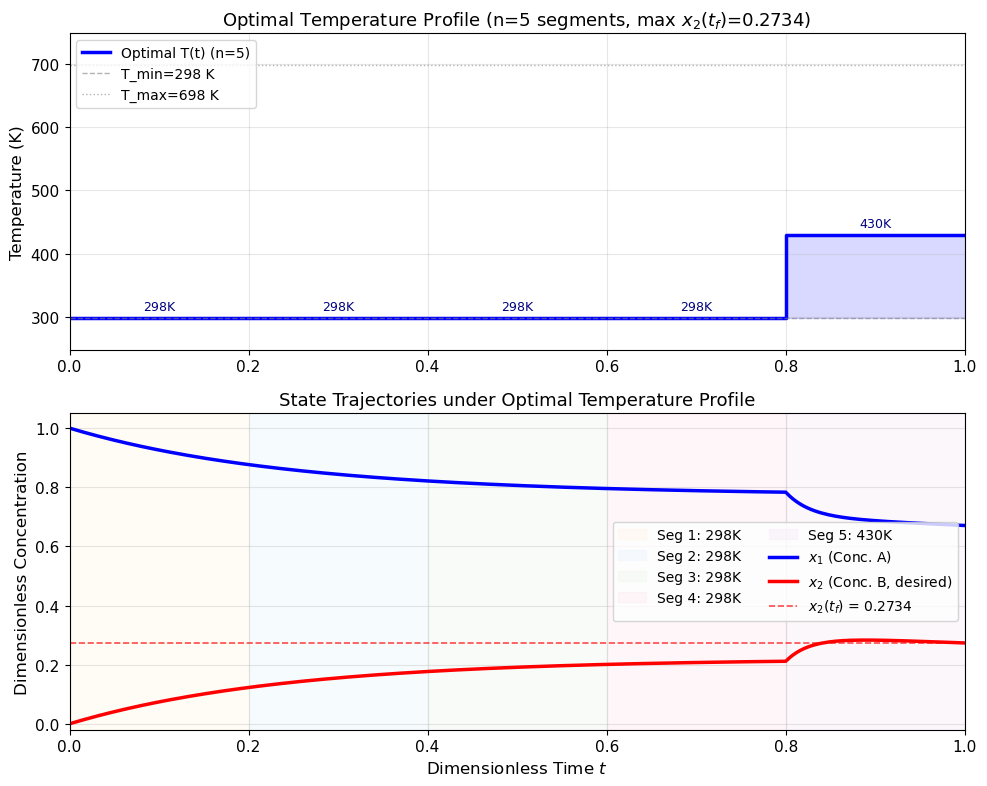


✓ 圖檔已儲存至: d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Example_05\figs\reactor_opt_n5.png


In [17]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=False)
t_seg = np.linspace(0, T_FINAL, N_SEG + 1)  # 分段邊界

# ---- 上圖: 最佳溫度分布 (Step Plot) ----
ax1 = axes[0]
# 建立階梯圖資料 (step='post')
t_step = np.repeat(t_seg, 2)[1:-1]   # [0, 0.2, 0.2, 0.4, 0.4, ..., 1.0]
T_step = np.repeat(T_opt, 2)          # [T1, T1, T2, T2, ..., Tn, Tn]
ax1.plot(t_step, T_step, 'b-', lw=2.5, label=f'Optimal T(t) (n={N_SEG})')
ax1.fill_between(t_step, T_MIN, T_step, alpha=0.15, color='blue')
# 標記各段溫度值
for j in range(N_SEG):
    t_mid = (t_seg[j] + t_seg[j+1]) / 2
    ax1.text(t_mid, T_opt[j] + 8, f'{T_opt[j]:.0f}K',
             ha='center', va='bottom', fontsize=9, color='navy')
ax1.axhline(T_MIN, color='gray', ls='--', lw=1, alpha=0.6, label=f'T_min={T_MIN:.0f} K')
ax1.axhline(T_MAX, color='gray', ls=':',  lw=1, alpha=0.6, label=f'T_max={T_MAX:.0f} K')
ax1.set_xlim(0, T_FINAL)
ax1.set_ylim(T_MIN - 50, T_MAX + 50)
ax1.set_ylabel('Temperature (K)')
ax1.set_title(f'Optimal Temperature Profile (n={N_SEG} segments, max $x_2(t_f)$={x2_max:.4f})')
ax1.legend(loc='upper left', framealpha=0.8)

# ---- 下圖: 狀態軌跡 ----
ax2 = axes[1]
# 以不同背景色區分各溫度段
colors_bg = ['#fff3e0', '#e3f2fd', '#e8f5e9', '#fce4ec', '#f3e5f5']
for j in range(N_SEG):
    ax2.axvspan(t_seg[j], t_seg[j+1], alpha=0.3,
                color=colors_bg[j % len(colors_bg)], label=f'Seg {j+1}: {T_opt[j]:.0f}K')
# 狀態曲線
ax2.plot(t_traj, y_traj[0], 'b-',  lw=2.5, label='$x_1$ (Conc. A)')
ax2.plot(t_traj, y_traj[1], 'r-',  lw=2.5, label='$x_2$ (Conc. B, desired)')
ax2.axhline(x_final_opt[1], color='red', ls='--', lw=1.2, alpha=0.7,
            label=f'$x_2(t_f)$ = {x_final_opt[1]:.4f}')
ax2.set_xlim(0, T_FINAL)
ax2.set_ylim(-0.02, 1.05)
ax2.set_xlabel('Dimensionless Time $t$')
ax2.set_ylabel('Dimensionless Concentration')
ax2.set_title('State Trajectories under Optimal Temperature Profile')
ax2.legend(loc='center right', framealpha=0.8, ncol=2)

plt.tight_layout()
fig_path = FIG_DIR / 'reactor_opt_n5.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ 圖檔已儲存至: {fig_path}")

---
### 6. 區段數 $n$ 的影響

探討以不同區段數 $n = 1, 3, 5, 10$ 求解時，最佳 $x_2(t_f)$ 的變化，以及對應最佳溫度分布的型態。

- $n=1$ ：等溫操作，單一溫度決策變數的最簡情形
- $n=3, 5, 10$ ：分段均勻溫度，自由度逐步增加，解趨近於真實連續最佳解

**注意**：本比較為說明用途，各 $n$ 值依序求解， $n=10$ 計算時間約 10–20 秒。

   n     x2_max  Wall time (s)  T_opt summary
----------------------------------------------------------------------
   1   0.241512           0.27  [356]
   3   0.262566           2.08  [298, 298, 403]
   5   0.273410           5.24  [298, 298, 298, 298, 430]
  10   0.288547          23.88  min=298K, max=474K, last=474K


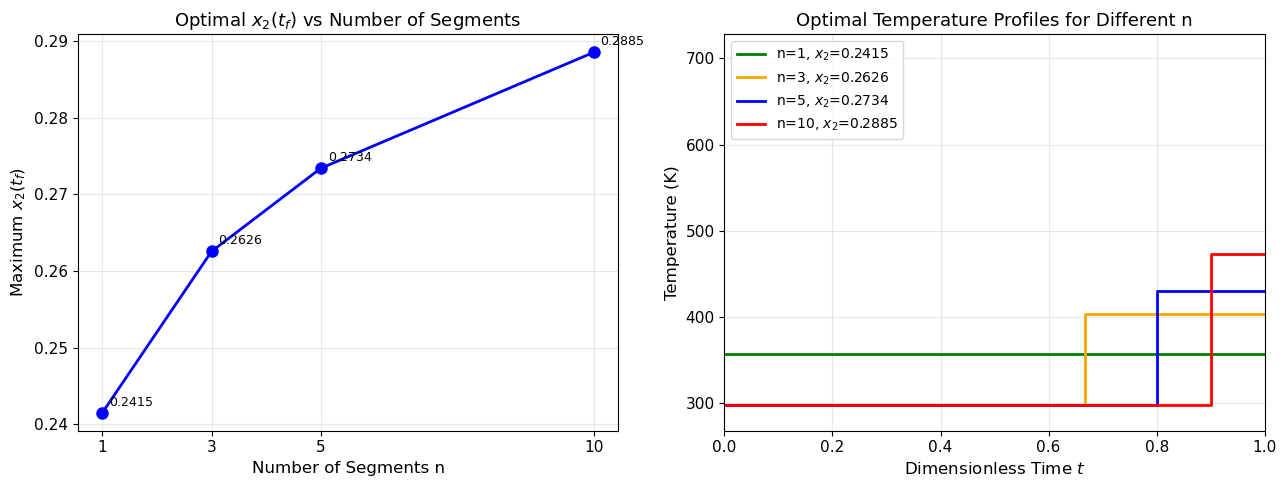


✓ 圖檔已儲存至: d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Example_05\figs\reactor_n_comparison.png


In [15]:
import time

n_values   = [1, 3, 5, 10]
x2_results = {}
T_results  = {}

print(f"{'n':>4} {'x2_max':>10} {'Wall time (s)':>14}  T_opt summary")
print("-" * 70)

for n in n_values:
    t_start = time.time()
    bounds_n = [(T_MIN, T_MAX)] * n
    best_x2_n = -np.inf
    best_T_n  = None
    
    for T0_val in [350.0, 420.0]:
        T0_n = np.full(n, T0_val)
        res_n = minimize(
            lambda T: -integrate_reactor(T)[2][1],
            T0_n,
            method='SLSQP',
            bounds=bounds_n,
            options={'ftol': 1e-10, 'maxiter': 2000}
        )
        if -res_n.fun > best_x2_n:
            best_x2_n = -res_n.fun
            best_T_n  = res_n.x.copy()
    
    elapsed = time.time() - t_start
    x2_results[n] = best_x2_n
    T_results[n]  = best_T_n
    
    if n <= 5:
        T_str = "[" + ", ".join([f"{t:.0f}" for t in best_T_n]) + "]"
    else:
        T_str = f"min={best_T_n.min():.0f}K, max={best_T_n.max():.0f}K, last={best_T_n[-1]:.0f}K"
    print(f"{n:>4} {best_x2_n:>10.6f} {elapsed:>14.2f}  {T_str}")

# 比較圖
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 左圖: x2_max vs n
ax_left = axes[0]
n_arr  = np.array(n_values)
x2_arr = np.array([x2_results[n] for n in n_values])
ax_left.plot(n_arr, x2_arr, 'bo-', ms=8, lw=2)
for n_i, x2_i in zip(n_arr, x2_arr):
    ax_left.annotate(f'{x2_i:.4f}', (n_i, x2_i), textcoords='offset points',
                     xytext=(5, 5), fontsize=9)
ax_left.set_xlabel('Number of Segments n')
ax_left.set_ylabel('Maximum $x_2(t_f)$')
ax_left.set_title('Optimal $x_2(t_f)$ vs Number of Segments')
ax_left.set_xticks(n_arr)

# 右圖: 各 n 的最佳溫度分布
ax_right = axes[1]
colors_n = ['green', 'orange', 'blue', 'red']
for i, n in enumerate(n_values):
    T_n   = T_results[n]
    t_seg_n = np.linspace(0, T_FINAL, n + 1)
    # 階梯圖
    t_step_n = np.repeat(t_seg_n, 2)[1:-1]
    T_step_n = np.repeat(T_n, 2)
    ax_right.plot(t_step_n, T_step_n, color=colors_n[i], lw=2,
                  label=f'n={n}, $x_2$={x2_results[n]:.4f}')
ax_right.set_xlabel('Dimensionless Time $t$')
ax_right.set_ylabel('Temperature (K)')
ax_right.set_title('Optimal Temperature Profiles for Different n')
ax_right.set_xlim(0, T_FINAL)
ax_right.set_ylim(T_MIN - 30, T_MAX + 30)
ax_right.legend(loc='upper left', framealpha=0.8)

plt.tight_layout()
fig_path2 = FIG_DIR / 'reactor_n_comparison.png'
plt.savefig(fig_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ 圖檔已儲存至: {fig_path2}")

---
### 7. SciPy 求解器組合說明

本範例結合 ODE 積分器與最適化求解器，以下為主要函式功能說明：

| 功能 | SciPy / Python | 說明 |
|:-----|:---------------|:-----|
| ODE 積分（非剛性） | `solve_ivp(method='RK45')` | 自適應步長 Runge-Kutta 積分器 |
| ODE 系統定義 | `lambda t, y: f(t, y)` | 匿名函式封裝 ODE 右側 |
| 多段積分 | `for` 迴圈銜接初值 | 逐段銜接各段終點作為下段初值 |
| 有界限制最適化 | `minimize(method='SLSQP', bounds=...)` | 序列二次規劃，處理有界 NLP |
| 邊界限制（向量） | `[(lb, ub)] * n` 或 `Bounds(lb, ub)` | 各段溫度上下界設定 |
| 初始猜測 | `np.full(n, 400.0)` | 均一初始溫度向量 |
| 最大化處理 | 對目標乘 `-1` | `minimize(-x2_tf)` 等價於 `maximize(x2_tf)` |

**注意**：`Bounds(lb, ub)` 使用純量時內部 broadcast，多 $n$ 比較時建議使用 `[(lb, ub)] * n` 的列表格式以避免廣播問題。

In [16]:
print("=" * 60)
print("  Unit12_Example_05 結果總結")
print("=" * 60)
print("\n問題: 管型反應器連串反應 A →(k1) B →(k3) C")
print("      dx1/dt = -k1*x1² + k2*x2")
print("      dx2/dt =  k1*x1² - (k2+k3)*x2")
print(f"      x0=[{x0_reactor[0]:.1f}, {x0_reactor[1]:.1f}], tf={T_FINAL:.1f}")
print(f"      T ∈ [{T_MIN:.0f}, {T_MAX:.0f}] K")
print()
print("分段均勻溫度最適化結果 (最佳起始猜測):")
print(f"  {'n':>4} {'最大 x2(tf)':>12} {'改善率(相對n=1)':>18}")
x2_ref = x2_results[1]
for n in n_values:
    improve = (x2_results[n] - x2_ref) / x2_ref * 100
    print(f"  {n:>4} {x2_results[n]:>12.6f} {improve:>16.2f}%")
print()
print("物理解釋:")
print("  最佳策略為「低-低-低-低-高」溫度分布，原因在於:")
print(f"  * k3 (B→C) 活化能 E3={E3:.0f} K 最高，低溫可抑制 B 降解")
print(f"  * k1 (A→B) 活化能 E1={E1:.0f} K，低溫亦能維持適度轉化率")
print(f"  * 末段短暫升溫促進殘餘 A 轉化為 B，提高終端 x2")
print()
print("SciPy 求解器組合:")
print("  solve_ivp(method='RK45')       → 精確 ODE 積分")
print("  minimize(method='SLSQP')       → 有界限制局部最適化")
print("  多起始點策略                    → 增加找到全域最適解的機會")
print()
print("輸出圖檔:")
print(f"  {FIG_DIR / 'reactor_opt_n5.png'}")
print(f"  {FIG_DIR / 'reactor_n_comparison.png'}")
print()
print("✓ Unit12_Example_05 執行完成")

  Unit12_Example_05 結果總結

問題: 管型反應器連串反應 A →(k1) B →(k3) C
      dx1/dt = -k1*x1² + k2*x2
      dx2/dt =  k1*x1² - (k2+k3)*x2
      x0=[1.0, 0.0], tf=1.0
      T ∈ [298, 698] K

分段均勻溫度最適化結果 (最佳起始猜測):
     n    最大 x2(tf)         改善率(相對n=1)
     1     0.241512             0.00%
     3     0.262566             8.72%
     5     0.273410            13.21%
    10     0.288547            19.48%

物理解釋:
  最佳策略為「低-低-低-低-高」溫度分布，原因在於:
  * k3 (B→C) 活化能 E3=3000 K 最高，低溫可抑制 B 降解
  * k1 (A→B) 活化能 E1=2500 K，低溫亦能維持適度轉化率
  * 末段短暫升溫促進殘餘 A 轉化為 B，提高終端 x2

SciPy 求解器組合:
  solve_ivp(method='RK45')       → 精確 ODE 積分
  minimize(method='SLSQP')       → 有界限制局部最適化
  多起始點策略                    → 增加找到全域最適解的機會

輸出圖檔:
  d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Example_05\figs\reactor_opt_n5.png
  d:\MyGit\ChemE-3502\Unit12\outputs\Unit12_Example_05\figs\reactor_n_comparison.png

✓ Unit12_Example_05 執行完成


---

**課程資訊**
- 課程名稱：電腦在化工上之應用 (ChemE 3502)
- 課程單元：Unit12 — 最佳化方法 (Optimization Methods)
- 課程製作：逢甲大學 化工系 智慧程序系統工程實驗室
- 授課教師：莊曜禎 助理教授
- 更新日期：2026-02-20

**課程授權 [CC BY-NC-SA 4.0]**
 - 本教材遵循 [創用CC 姓名標示-非商業性-相同方式分享 4.0 國際 (CC BY-NC-SA 4.0)](https://creativecommons.org/licenses/by-nc-sa/4.0/deed.zh) 授權。